# Kasus 3: Simulasi Pemetaan Zona Kriminalitas (Crime Zoning) di Vancouver

**Algoritma:** XGBoost Classifier | **Dataset:** Vancouver Crime (Kaggle)

## Import Library

In [54]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score, jaccard_score
from matplotlib.patches import Patch
import joblib
import time
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')
print('Semua library berhasil diimport')
VIZ_DIR = 'visualisasi_laporan'
os.makedirs(VIZ_DIR, exist_ok=True)


Semua library berhasil diimport


## Data Acquisition & Ingestion

In [55]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vTku1DXWMvGUUu1krNlP9oquEr1U_yGBJFglnbvolCtM60CbtJw4_x-FP_Za-CWn9hHMTRrYCkIc_5K/pub?gid=1321136410&single=true&output=csv"
df_crime = pd.read_csv(url)

print(f"Data berhasil dimuat: {len(df_crime)} baris")
print(f"Kolom: {df_crime.columns.tolist()}")
print(f"\nMissing values:\n{df_crime.isnull().sum()}")

# Validasi Spasial - Filter koordinat invalid (0,0 atau NaN)
valid_mask = (
    (df_crime['X'] != 0) & (df_crime['Y'] != 0) &
    df_crime['X'].notna() & df_crime['Y'].notna()
)
df_clean = df_crime[valid_mask].copy().reset_index(drop=True)

# HOUR bisa mengandung NaN isi dengan median
df_clean['HOUR'] = df_clean['HOUR'].fillna(df_clean['HOUR'].median()).astype(int)

print(f"\nSetelah filter koordinat valid: {len(df_clean)} baris")
print(f"Rentang X: {df_clean['X'].min():.2f} - {df_clean['X'].max():.2f}")
print(f"Rentang Y: {df_clean['Y'].min():.2f} - {df_clean['Y'].max():.2f}")
print(f"\nDistribusi TYPE:\n{df_clean['TYPE'].value_counts()}")


Data berhasil dimuat: 530652 baris
Kolom: ['TYPE', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude', 'Longitude']

Missing values:
TYPE                 0
YEAR                 0
MONTH                0
DAY                  0
HOUR             54362
MINUTE           54362
HUNDRED_BLOCK       13
NEIGHBOURHOOD    56624
X                    0
Y                    0
Latitude             0
Longitude            0
dtype: int64

Setelah filter koordinat valid: 476290 baris
Rentang X: 388373.00 - 511303.00
Rentang Y: 5435925.00 - 5512579.00

Distribusi TYPE:
TYPE
Theft from Vehicle                                        172700
Mischief                                                   70413
Break and Enter Residential/Other                          60862
Other Theft                                                52167
Theft of Vehicle                                           38418
Break and Enter Commercial                                 33845
Theft

## EDA & Visualisasi

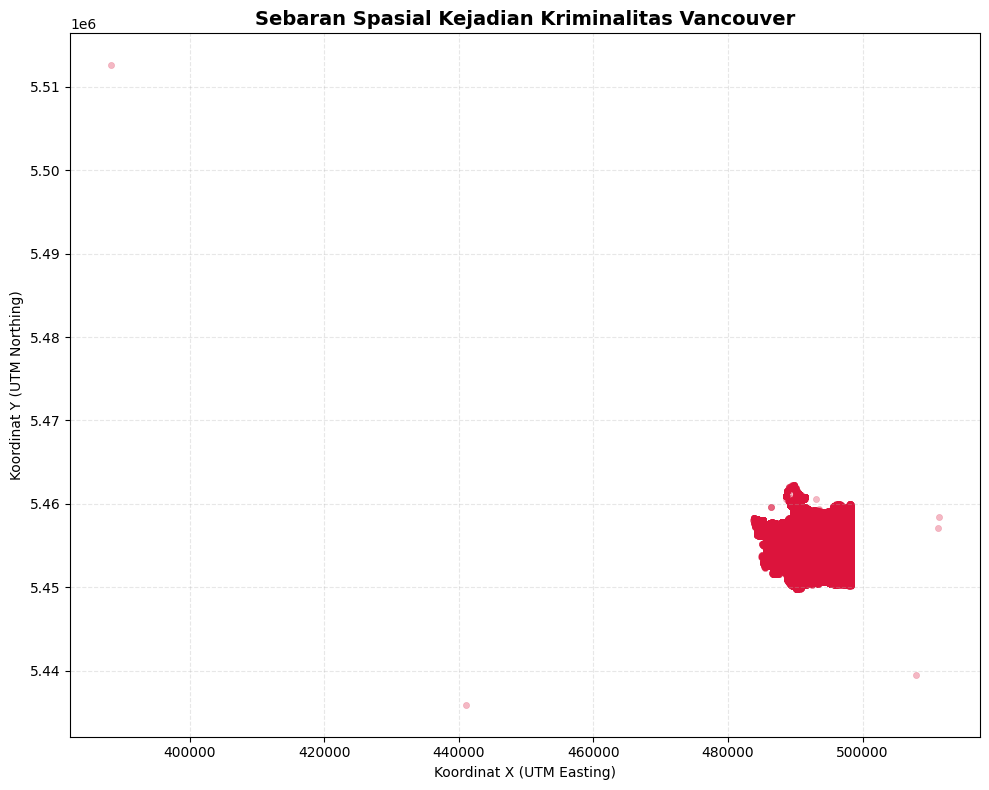

In [56]:
# Scatter plot spasial
plt.figure(figsize=(10, 8))
sns.scatterplot(x='X', y='Y', data=df_clean, alpha=0.3, color='crimson', s=20, edgecolor=None)
plt.title('Sebaran Spasial Kejadian Kriminalitas Vancouver', fontsize=14, fontweight='bold')
plt.xlabel('Koordinat X (UTM Easting)')
plt.ylabel('Koordinat Y (UTM Northing)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig(f'{VIZ_DIR}/01_eda_sebaran_spasial.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

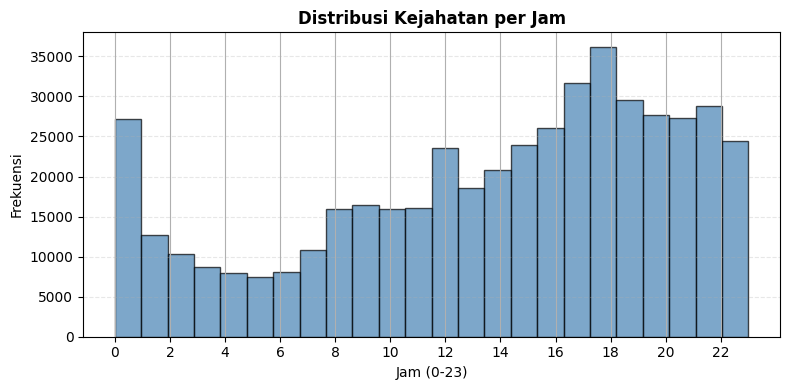

In [57]:
# Distribusi kejahatan per jam
plt.figure(figsize=(8, 4))
df_clean['HOUR'].hist(bins=24, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribusi Kejahatan per Jam', fontsize=12, fontweight='bold')
plt.xlabel('Jam (0-23)'); plt.ylabel('Frekuensi')
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(f'{VIZ_DIR}/02_eda_distribusi_jam.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

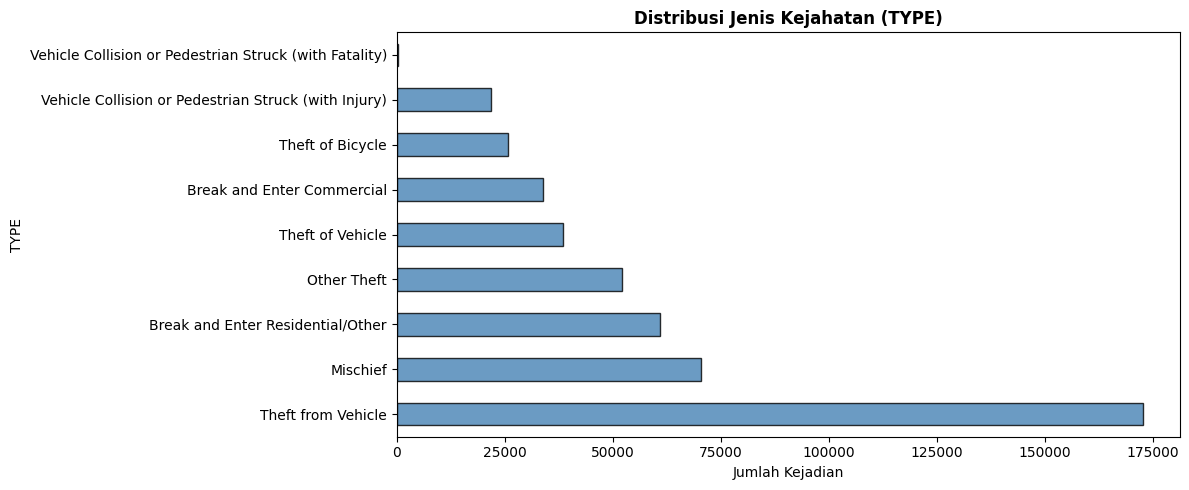

In [58]:
# Tambahkan distribusi TYPE
plt.figure(figsize=(12, 5))
df_clean['TYPE'].value_counts().plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribusi Jenis Kejahatan (TYPE)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Kejadian')
plt.savefig(f'{VIZ_DIR}/03_eda_distribusi_TYPE.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Identification Phase: Elbow Method

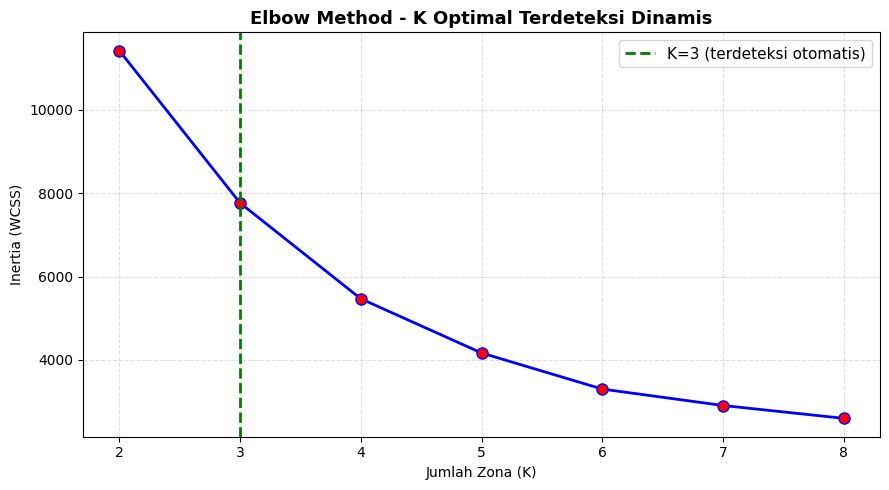

K optimal terdeteksi: 3
Dasar: penurunan inertia pertama kali < 10% terjadi di K=3


In [59]:
# Elbow Method - Deteksi K Optimal DINAMIS
from sklearn.cluster import KMeans

N_ELBOW = min(10000, len(df_clean))
np.random.seed(42)
sample_idx_elbow = np.random.choice(len(df_clean), size=N_ELBOW, replace=False)
X_elbow = StandardScaler().fit_transform(df_clean[['X','Y']].iloc[sample_idx_elbow].values)

inertias = []
k_range = range(2, 9)  # batasi 2-8 agar tidak terlalu lebar

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(X_elbow)
    inertias.append(km.inertia_)

# ---- Deteksi dinamis: cari K pertama di mana penurunan inertia < threshold ----
THRESHOLD_PCT = 10  # penurunan di bawah 10% dianggap tidak signifikan
OPTIMAL_K = 3       # default fallback
for i in range(1, len(inertias)):
    drop_pct = (inertias[i-1] - inertias[i]) / inertias[i-1] * 100
    if drop_pct < THRESHOLD_PCT:
        OPTIMAL_K = list(k_range)[i]  # K pertama di mana penurunan melambat
        break

# Safety: pastikan K minimal 2
OPTIMAL_K = max(2, OPTIMAL_K)

# Grafik Elbow
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
plt.axvline(x=OPTIMAL_K, color='green', linestyle='--', linewidth=2,
            label=f'K={OPTIMAL_K} (terdeteksi otomatis)')
plt.title('Elbow Method - K Optimal Terdeteksi Dinamis', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Zona (K)'); plt.ylabel('Inertia (WCSS)')
plt.xticks(list(k_range)); plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(f'{VIZ_DIR}/04_elbow_method.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

print(f'K optimal terdeteksi: {OPTIMAL_K}')
print(f'Dasar: penurunan inertia pertama kali < {THRESHOLD_PCT}% terjadi di K={OPTIMAL_K}')

## Spatial Density Feature Engineering (Pseudo-Label Generator)

In [60]:
# Spatial Density Feature Engineering
print('Membuat fitur densitas spasial dengan grid lebih halus')

# Tingkatkan resolusi grid dari 20 menjadi 100
N_BINS = 100  # Lebih halus untuk handle koordinat identik

grid_size_x = (df_clean['X'].max() - df_clean['X'].min()) / N_BINS
grid_size_y = (df_clean['Y'].max() - df_clean['Y'].min()) / N_BINS
if grid_size_x == 0: grid_size_x = 1
if grid_size_y == 0: grid_size_y = 1

df_clean['grid_x'] = np.clip(
    ((df_clean['X'] - df_clean['X'].min()) / grid_size_x).astype(int),
    0, N_BINS-1)
df_clean['grid_y'] = np.clip(
    ((df_clean['Y'] - df_clean['Y'].min()) / grid_size_y).astype(int),
    0, N_BINS-1)
df_clean['grid_id'] = df_clean['grid_x'].astype(str) + '_' + df_clean['grid_y'].astype(str)

grid_counts = df_clean.groupby('grid_id').size()
df_clean['grid_density'] = df_clean['grid_id'].map(grid_counts)

dens_min = df_clean['grid_density'].min()
dens_max = df_clean['grid_density'].max()
if dens_max - dens_min > 1e-8:
    df_clean['density_norm'] = (df_clean['grid_density'] - dens_min) / (dens_max - dens_min)
else:
    df_clean['density_norm'] = 0.5

def create_pseudo_labels(density_series, n_zones=3):
    """Membuat label zona dengan fallback mechanism"""
    labels = [f'Z{i+1}' for i in range(n_zones)]
    try:
        return pd.qcut(density_series, q=n_zones, labels=labels, duplicates='drop')
    except ValueError:
        print('pd.qcut gagal, mencoba pd.cut...')
        try:
            return pd.cut(density_series, bins=n_zones, labels=labels, include_lowest=True)
        except ValueError:
            print('pd.cut gagal, menggunakan manual binning...')
            med = density_series.median()
            q75 = density_series.quantile(0.75)
            return density_series.apply(
                lambda x: 'LOW' if x <= med else ('MEDIUM' if x <= q75 else 'HIGH'))

df_clean['pseudo_zone'] = create_pseudo_labels(df_clean['density_norm'], n_zones=OPTIMAL_K)
if df_clean['pseudo_zone'].isna().any():
    df_clean['pseudo_zone'] = df_clean['pseudo_zone'].fillna(df_clean['pseudo_zone'].mode()[0])
df_clean['pseudo_zone'] = df_clean['pseudo_zone'].astype('category')

print('Fitur densitas dan pseudo-label berhasil dibuat:')
print(df_clean[['X','Y','grid_density','density_norm','pseudo_zone']].head(10))
print(f'\nDistribusi zona:\n{df_clean["pseudo_zone"].value_counts().sort_index()}')

# Diagnosa tambahan
print(f'\nStatistik Grid:')
print(f'  Jumlah grid unik: {df_clean["grid_id"].nunique()}')
print(f'  Rata-rata density per grid: {df_clean["grid_density"].mean():.2f}')
print(f'  Max density: {df_clean["grid_density"].max()}')
print(f'  Min density: {df_clean["grid_density"].min()}')

Membuat fitur densitas spasial dengan grid lebih halus
Fitur densitas dan pseudo-label berhasil dibuat:
           X           Y  grid_density  density_norm pseudo_zone
0  493906.50  5457452.47          2122      0.046723          Z1
1  493906.50  5457452.47          2122      0.046723          Z1
2  493906.50  5457452.47          2122      0.046723          Z1
3  493906.50  5457452.47          2122      0.046723          Z1
4  493906.50  5457452.47          2122      0.046723          Z1
5  493906.50  5457452.47          2122      0.046723          Z1
6  489325.58  5452817.95          1208      0.026589          Z1
7  485903.09  5455883.77          1818      0.040026          Z1
8  493906.50  5457452.47          2122      0.046723          Z1
9  495078.19  5457221.38          5659      0.124639          Z2

Distribusi zona:
pseudo_zone
Z1    159192
Z2    163884
Z3    153214
Name: count, dtype: int64

Statistik Grid:
  Jumlah grid unik: 164
  Rata-rata density per grid: 12297.56
  Max 

## Temporal Engineering & Feature Preparation

In [61]:
# Temporal Engineering & Feature Preparation
print('Membuat fitur temporal & scaling...')

# Pastikan tidak ada NaN di kolom waktu (safety guard)
df_clean['HOUR'] = df_clean['HOUR'].fillna(df_clean['HOUR'].median()).astype(int)
df_clean['MONTH'] = df_clean['MONTH'].fillna(df_clean['MONTH'].median()).astype(int)

# Fitur temporal
df_clean['TIME_CATEGORY'] = df_clean['HOUR'].apply(lambda h: 'Siang' if 6 <= h < 18 else 'Malam')
df_clean['HOUR_BIN'] = df_clean['TIME_CATEGORY'].map({'Siang': 0, 'Malam': 1})
df_clean['HOUR_SIN'] = np.sin(2 * np.pi * df_clean['HOUR'] / 24)
df_clean['HOUR_COS'] = np.cos(2 * np.pi * df_clean['HOUR'] / 24)

# Cyclical encoding MONTH
df_clean['MONTH_SIN'] = np.sin(2 * np.pi * df_clean['MONTH'] / 12)
df_clean['MONTH_COS'] = np.cos(2 * np.pi * df_clean['MONTH'] / 12)

# Encoding label zona (dinamis mengikuti OPTIMAL_K dari Cell 4 & 5)
label_encoder = LabelEncoder()
df_clean['zone_label'] = label_encoder.fit_transform(df_clean['pseudo_zone'])

# Scaling koordinat
scaler_xy = StandardScaler()
df_clean[['X_scaled','Y_scaled']] = scaler_xy.fit_transform(df_clean[['X','Y']])

# Susun fitur
feature_cols = ['X_scaled','Y_scaled','HOUR_BIN','HOUR_SIN','HOUR_COS','MONTH_SIN','MONTH_COS']
X = df_clean[feature_cols]
y = df_clean['zone_label']

print(' Fitur siap untuk training XGBoost:')
print(X.head())
print(f'\n Shape: {X.shape}')
print(f' Target: {len(np.unique(y))} kelas -> {label_encoder.classes_.tolist()}')

Membuat fitur temporal & scaling...
 Fitur siap untuk training XGBoost:
   X_scaled  Y_scaled  HOUR_BIN  HOUR_SIN  HOUR_COS  MONTH_SIN  MONTH_COS
0  0.611524  0.315608         0 -0.866025 -0.500000   0.500000  -0.866025
1  0.611524  0.315608         0 -0.707107 -0.707107   0.500000  -0.866025
2  0.611524  0.315608         0 -0.866025 -0.500000   0.866025  -0.500000
3  0.611524  0.315608         0  0.258819 -0.965926   0.866025  -0.500000
4  0.611524  0.315608         0 -0.965926 -0.258819   0.866025  -0.500000

 Shape: (476290, 7)
 Target: 3 kelas -> ['Z1', 'Z2', 'Z3']


## XGBoost Model Training

Train: 381,032 | Test: 95,258
Akurasi Training : 99.73%
Akurasi Testing  : 99.62%
CV Accuracy 5-fold: 99.63% +/- 0.03%

Classification Report:
              precision    recall  f1-score   support

          Z1       1.00      1.00      1.00     31838
          Z2       1.00      0.99      0.99     32777
          Z3       1.00      1.00      1.00     30643

    accuracy                           1.00     95258
   macro avg       1.00      1.00      1.00     95258
weighted avg       1.00      1.00      1.00     95258



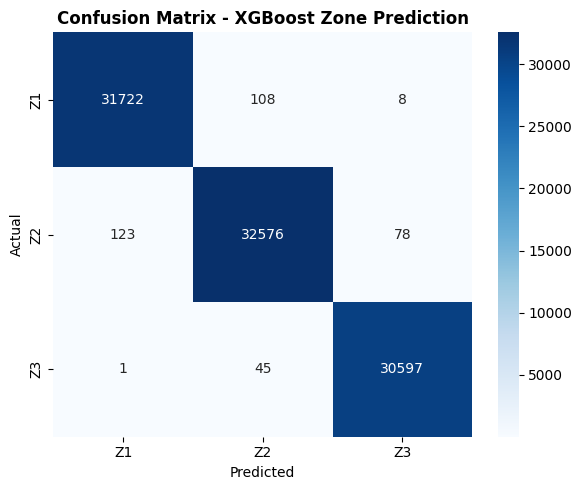

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# PERBAIKAN: Hapus use_label_encoder=False (deprecated di XGBoost >= 1.6)
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, eval_metric='mlogloss',
    tree_method='hist',
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)
acc = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print(f'Akurasi Training : {xgb_model.score(X_train, y_train)*100:.2f}%')
print(f'Akurasi Testing  : {acc*100:.2f}%')
print(f'CV Accuracy 5-fold: {cv_scores.mean()*100:.2f}% +/- {cv_scores.std()*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - XGBoost Zone Prediction', fontsize=12, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig(f'{VIZ_DIR}/05_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

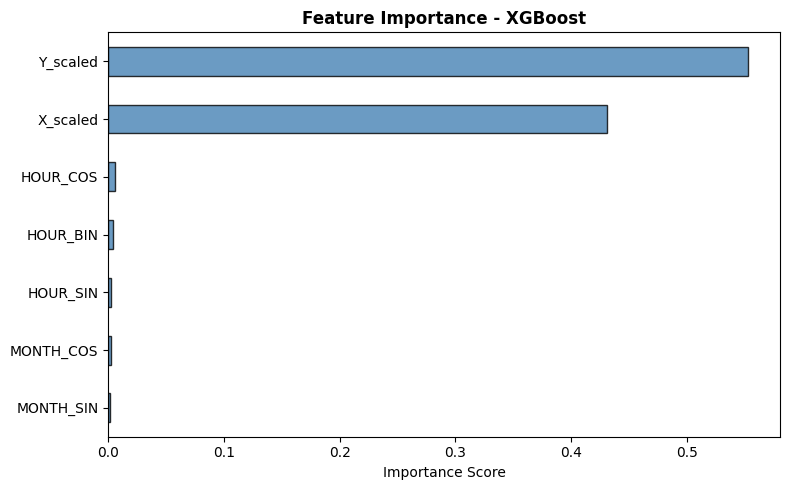

In [64]:
# Feature Importance
plt.figure(figsize=(8, 5))
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Feature Importance - XGBoost', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.savefig(f'{VIZ_DIR}/06_feature_importance.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Validation Phase: Silhouette Score & Jaccard Stability

VALIDATION PHASE
Menghitung Silhouette Score pada 8,000 sampel...
    Silhouette Score: 0.1166 | Waktu: 1.27s
     Interpretasi: >0.50=Jelas | 0.25-0.50=Cukup | <0.25=Samar

 Uji Stabilitas Jaccard Index dengan Noise...
    Jaccard Index: 0.8677 | Waktu: 0.08s
     Interpretasi: >0.80=Sangat Stabil | 0.60-0.80=Cukup | <0.60=Rentan
    Konsistensi Prediksi: 92.80%


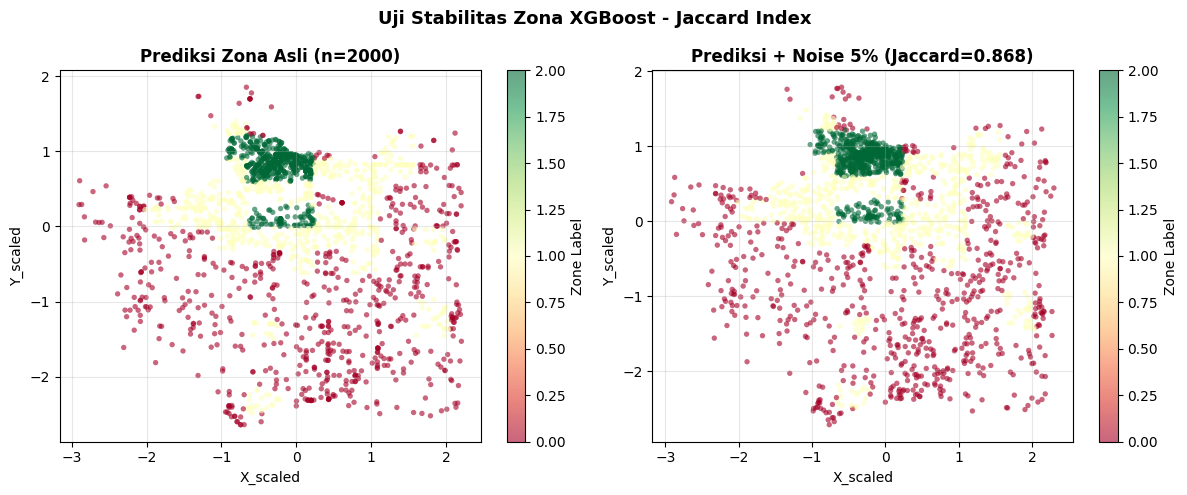


Ringkasan Validasi:
  Silhouette Score : 0.1166 (1.27s)
  Jaccard Index    : 0.8677 (0.08s)
  Consistency      : 92.80%
  Total Waktu   : 2.86 detik


In [65]:
print('='*60)
print('VALIDATION PHASE')
print('='*60)
start_time = time.time()

# 1. Silhouette Score (Sampling 8.000 untuk performa O(N))
N_MAX = 8000
n_sil = min(N_MAX, len(df_clean))
np.random.seed(42)
sil_idx = np.random.choice(len(df_clean), size=n_sil, replace=False)
X_sil = df_clean[['X_scaled','Y_scaled']].iloc[sil_idx].values
y_sil = df_clean['zone_label'].iloc[sil_idx].values

print(f'Menghitung Silhouette Score pada {n_sil:,} sampel...')
t_sil_start = time.time()
sil_score = silhouette_score(X_sil, y_sil)
t_sil = time.time() - t_sil_start
print(f'    Silhouette Score: {sil_score:.4f} | Waktu: {t_sil:.2f}s')
print('     Interpretasi: >0.50=Jelas | 0.25-0.50=Cukup | <0.25=Samar')

# 2. Jaccard Stability Test (Noise Injection)
print(f'\n Uji Stabilitas Jaccard Index dengan Noise...')
np.random.seed(123)
sample_size = min(2000, len(X))
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx].copy()

t_jac_start = time.time()
labels_original = xgb_model.predict(X_sample)

# Tambahkan noise ±5% pada koordinat ter-skalasi
noise_level = 0.05
X_noisy = X_sample.copy()
X_noisy[['X_scaled','Y_scaled']] += np.random.normal(0, noise_level, size=(len(X_sample), 2))
labels_noisy = xgb_model.predict(X_noisy)

# Tambah zero_division=0 agar tidak warning jika kelas tidak lengkap di sampel
jaccard = jaccard_score(labels_original, labels_noisy, average='macro', zero_division=0)
consistency = (labels_original == labels_noisy).mean()
t_jac = time.time() - t_jac_start

print(f'    Jaccard Index: {jaccard:.4f} | Waktu: {t_jac:.2f}s')
print('     Interpretasi: >0.80=Sangat Stabil | 0.60-0.80=Cukup | <0.60=Rentan')
print(f'    Konsistensi Prediksi: {consistency*100:.2f}%')

# Visualisasi Stabilitas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc1 = axes[0].scatter(X_sample['X_scaled'], X_sample['Y_scaled'],
                      c=labels_original, cmap='RdYlGn', alpha=0.6, s=15, edgecolor='none')
axes[0].set_title(f'Prediksi Zona Asli (n={sample_size})', fontweight='bold')
axes[0].set_xlabel('X_scaled'); axes[0].set_ylabel('Y_scaled'); axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Zone Label')

sc2 = axes[1].scatter(X_noisy['X_scaled'], X_noisy['Y_scaled'],
                      c=labels_noisy, cmap='RdYlGn', alpha=0.6, s=15, edgecolor='none')
axes[1].set_title(f'Prediksi + Noise 5% (Jaccard={jaccard:.3f})', fontweight='bold')
axes[1].set_xlabel('X_scaled'); axes[1].set_ylabel('Y_scaled'); axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Zone Label')

plt.suptitle('Uji Stabilitas Zona XGBoost - Jaccard Index', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/07_Uji_Stabilitas_Zone.png', dpi=300, bbox_inches='tight')
plt.tight_layout(); plt.show()

print(f'\nRingkasan Validasi:')
print(f'  Silhouette Score : {sil_score:.4f} ({t_sil:.2f}s)')
print(f'  Jaccard Index    : {jaccard:.4f} ({t_jac:.2f}s)')
print(f'  Consistency      : {consistency*100:.2f}%')
print(f'  Total Waktu   : {time.time()-start_time:.2f} detik')

## Profiling, Labeling & Security Simulation

In [66]:
# Profiling, Labeling & Security Simulation (DINAMIS)
zone_profiles = df_clean.groupby('pseudo_zone', observed=True).agg(
    X_mean=('X','mean'), X_std=('X','std'),
    Y_mean=('Y','mean'), Y_std=('Y','std'),
    HOUR_mean=('HOUR','mean'),
    count=('TYPE','count'),
    avg_density=('density_norm','mean')
).round(3)

# ⭐ SORTING DINAMIS: Zona terpadat = paling rawan
zone_profiles = zone_profiles.sort_values('avg_density', ascending=False)
zones = zone_profiles.index.tolist()

# Mapping risiko otomatis berdasarkan urutan densitas
risk_mapping = {}
for i, z in enumerate(zones):
    if i == 0: risk_mapping[z] = 'MERAH (Sangat Rawan)'
    elif i == 1: risk_mapping[z] = 'KUNING (Rawan)'
    elif i == 2: risk_mapping[z] = 'HIJAU (Aman)'
    else: risk_mapping[z] = f'HIJAU-{i} (Aman)'  # Fallback jika K > 3

zone_profiles['risk_label'] = zone_profiles.index.map(risk_mapping)
print('Profil Zona Kriminalitas (Dinamis):')
print(zone_profiles[['count','avg_density','HOUR_mean','risk_label']].to_string())

# ⭐ FUNGSI SIMULATOR DINAMIS
def predict_zone_xgboost(utm_x, utm_y, hour):
    coords_scaled = scaler_xy.transform([[utm_x, utm_y]])[0]
    hour_bin = 0 if 6 <= hour < 18 else 1
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    month_med = df_clean['MONTH'].median()
    month_sin = np.sin(2 * np.pi * month_med / 12)
    month_cos = np.cos(2 * np.pi * month_med / 12)

    input_features = pd.DataFrame([{
        'X_scaled': coords_scaled[0], 'Y_scaled': coords_scaled[1],
        'HOUR_BIN': hour_bin, 'HOUR_SIN': hour_sin, 'HOUR_COS': hour_cos,
        'MONTH_SIN': month_sin, 'MONTH_COS': month_cos
    }])

    zone_pred_encoded = xgb_model.predict(input_features)[0]
    zone_pred = label_encoder.inverse_transform([zone_pred_encoded])[0]
    risk_label = risk_mapping.get(zone_pred, 'HIJAU (Aman)')

    # Tentukan skor & rekomendasi secara dinamis
    if 'MERAH' in risk_label:
        recommendation = 'PATROLI INTENSIF: 2+ unit/shift + CCTV + community policing'
        efficiency = 'Prioritas Maksimum'; risk_score = 3
    elif 'KUNING' in risk_label:
        recommendation = 'PATROLI REGULER: 1 unit/shift + monitoring berkala'
        efficiency = 'Efisien dengan evaluasi bulanan'; risk_score = 2
    else:
        recommendation = 'PATROLI RUTIN: Responsif terhadap laporan warga'
        efficiency = 'Sangat Efisien'; risk_score = 1

    proba = xgb_model.predict_proba(input_features)[0]
    confidence = np.max(proba) * 100
    return {
        'zone': zone_pred, 'zone_encoded': int(zone_pred_encoded),
        'risk_label': risk_label, 'risk_score': risk_score,
        'security_recommendation': recommendation,
        'coverage_efficiency': efficiency, 'confidence': confidence,
        'prediction_proba': dict(zip(label_encoder.classes_, proba))
    }

print('\n✅ Simulator XGBoost siap! (Mendukung K dinamis)')

Profil Zona Kriminalitas (Dinamis):
              count  avg_density  HOUR_mean            risk_label
pseudo_zone                                                      
Z3           153214        0.648     13.591  MERAH (Sangat Rawan)
Z2           163884        0.140     13.735        KUNING (Rawan)
Z1           159192        0.043     13.803          HIJAU (Aman)

✅ Simulator XGBoost siap! (Mendukung K dinamis)


PROFILING ZONA & SECURITY SIMULATION

 PROFIL ZONA KRIMINALITAS:
              count  avg_density  HOUR_mean            risk_label
pseudo_zone                                                      
Z3           153214        0.648     13.591  MERAH (Sangat Rawan)
Z2           163884        0.140     13.735        KUNING (Rawan)
Z1           159192        0.043     13.803          HIJAU (Aman)


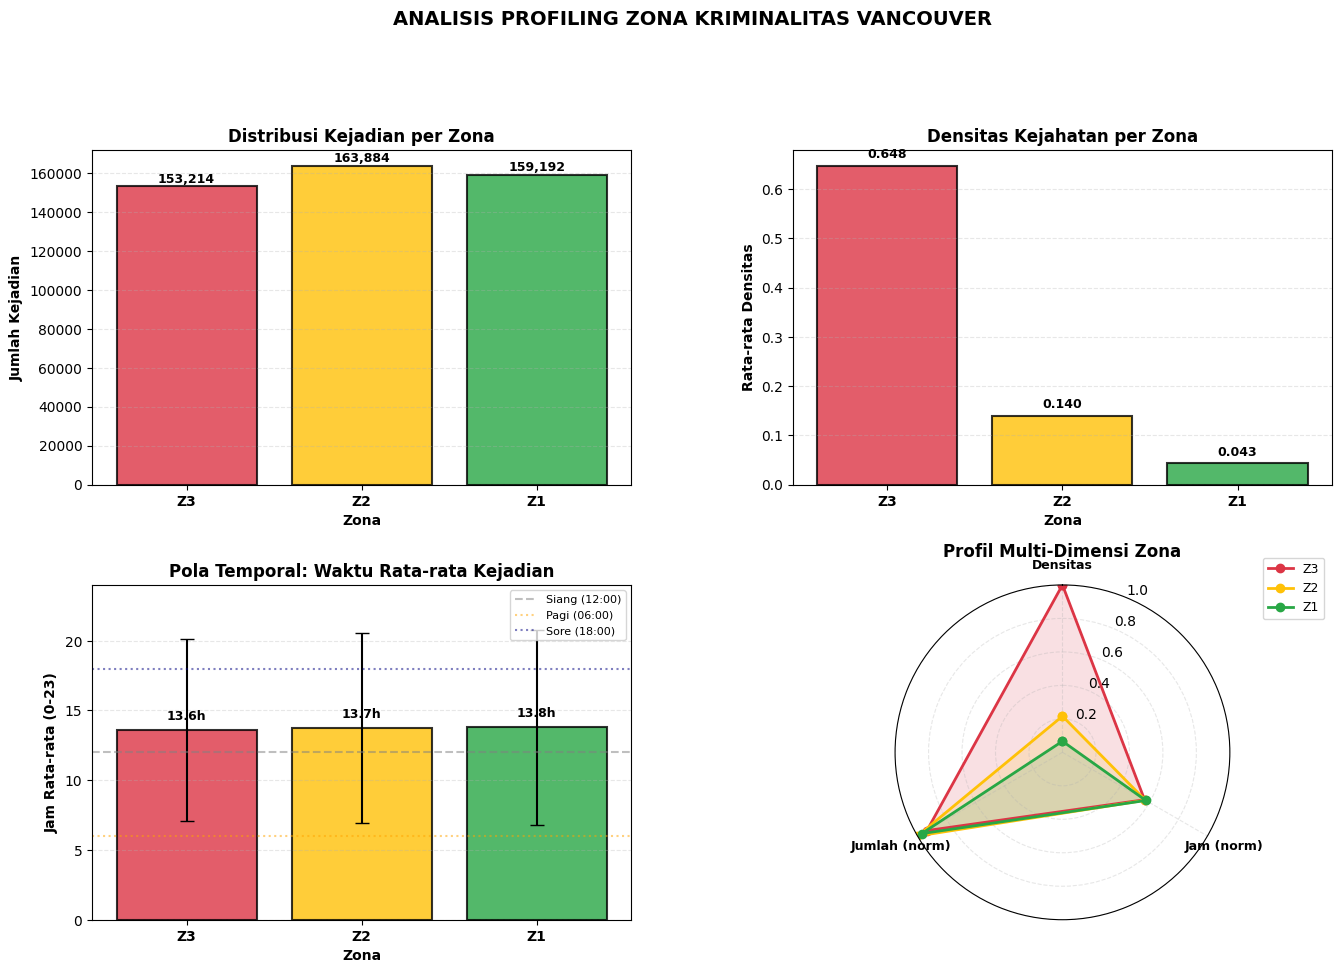


CONTOH HASIL SIMULATOR:
----------------------------------------------------------------------

Contoh 1: Koordinat (491773.9, 5457264.3) pada jam 14:00
  Zona        : Z3
  Risiko      : MERAH (Sangat Rawan)
  Confidence  : 99.9%
  Rekomendasi :  PATROLI INTENSIF: 2+ unit/shift + CCTV + community policing
  Efisiensi   :  Prioritas Maksimum

Contoh 2: Koordinat (491773.9, 5457264.3) pada jam 23:00
  Zona        : Z3
  Risiko      : MERAH (Sangat Rawan)
  Confidence  : 99.9%
  Rekomendasi :  PATROLI INTENSIF: 2+ unit/shift + CCTV + community policing
  Efisiensi   :  Prioritas Maksimum

Contoh 3: Koordinat (490593.6, 5455158.3) pada jam 02:00
  Zona        : Z1
  Risiko      : HIJAU (Aman)
  Confidence  : 99.5%
  Rekomendasi :  PATROLI RUTIN: Responsif terhadap laporan warga
  Efisiensi   :  Sangat Efisien


In [67]:
# Profiling, Labeling & Security Simulation (ENHANCED VISUALIZATION)
print('='*70)
print('PROFILING ZONA & SECURITY SIMULATION')
print('='*70)

# 1. PROFILING ZONA
zone_profiles = df_clean.groupby('pseudo_zone', observed=True).agg(
    X_mean=('X','mean'), X_std=('X','std'),
    Y_mean=('Y','mean'), Y_std=('Y','std'),
    HOUR_mean=('HOUR','mean'),
    count=('TYPE','count'),
    avg_density=('density_norm','mean'),
    HOUR_std=('HOUR','std')
).round(3)

# Sorting: Zona terpadat = paling rawan
zone_profiles = zone_profiles.sort_values('avg_density', ascending=False)
zones = zone_profiles.index.tolist()

# Mapping risiko dinamis berdasarkan urutan densitas
risk_mapping = {}
risk_colors = {}
for i, z in enumerate(zones):
    if i == 0:
        risk_mapping[z] = 'MERAH (Sangat Rawan)'
        risk_colors[z] = '#dc3545'  # Red
    elif i == 1:
        risk_mapping[z] = 'KUNING (Rawan)'
        risk_colors[z] = '#ffc107'  # Yellow/Orange
    elif i == 2:
        risk_mapping[z] = 'HIJAU (Aman)'
        risk_colors[z] = '#28a745'  # Green
    else:
        risk_mapping[z] = f'HIJAU-{i} (Aman)'
        risk_colors[z] = '#17a2b8'  # Blue/Cyan

zone_profiles['risk_label'] = zone_profiles.index.map(risk_mapping)
zone_profiles['risk_color'] = zone_profiles.index.map(risk_colors)

print('\n PROFIL ZONA KRIMINALITAS:')
print(zone_profiles[['count','avg_density','HOUR_mean','risk_label']].to_string())

# 2. VISUALISASI PROFILING (4 Panel)
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel 1: Jumlah Kejadian per Zona
ax1 = fig.add_subplot(gs[0, 0])
colors_zone = [risk_colors[z] for z in zone_profiles.index]
bars1 = ax1.bar(range(len(zone_profiles)), zone_profiles['count'],
                color=colors_zone, edgecolor='black', alpha=0.8, linewidth=1.5)
ax1.set_xlabel('Zona', fontweight='bold')
ax1.set_ylabel('Jumlah Kejadian', fontweight='bold')
ax1.set_title('Distribusi Kejadian per Zona', fontweight='bold', fontsize=12)
ax1.set_xticks(range(len(zone_profiles)))
ax1.set_xticklabels(zone_profiles.index, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Tambahkan label nilai di atas bar
for bar, count in zip(bars1, zone_profiles['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{int(count):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Rata-rata Densitas per Zona
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(range(len(zone_profiles)), zone_profiles['avg_density'],
                color=colors_zone, edgecolor='black', alpha=0.8, linewidth=1.5)
ax2.set_xlabel('Zona', fontweight='bold')
ax2.set_ylabel('Rata-rata Densitas', fontweight='bold')
ax2.set_title('Densitas Kejahatan per Zona', fontweight='bold', fontsize=12)
ax2.set_xticks(range(len(zone_profiles)))
ax2.set_xticklabels(zone_profiles.index, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.3)

for bar, dens in zip(bars2, zone_profiles['avg_density']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{dens:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Pola Waktu (Jam Rata-rata) per Zona
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(range(len(zone_profiles)), zone_profiles['HOUR_mean'],
                color=colors_zone, edgecolor='black', alpha=0.8, linewidth=1.5,
                yerr=zone_profiles['HOUR_std'], capsize=5, error_kw={'elinewidth':1.5})
ax3.set_xlabel('Zona', fontweight='bold')
ax3.set_ylabel('Jam Rata-rata (0-23)', fontweight='bold')
ax3.set_title('Pola Temporal: Waktu Rata-rata Kejadian', fontweight='bold', fontsize=12)
ax3.set_xticks(range(len(zone_profiles)))
ax3.set_xticklabels(zone_profiles.index, fontweight='bold')
ax3.set_ylim(0, 24)
ax3.axhline(y=12, color='gray', linestyle='--', alpha=0.5, label='Siang (12:00)')
ax3.axhline(y=6, color='orange', linestyle=':', alpha=0.5, label='Pagi (06:00)')
ax3.axhline(y=18, color='navy', linestyle=':', alpha=0.5, label='Sore (18:00)')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(axis='y', linestyle='--', alpha=0.3)

for bar, hour in zip(bars3, zone_profiles['HOUR_mean']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{hour:.1f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Radar Chart - Karakteristik Zona
ax4 = fig.add_subplot(gs[1, 1], projection='polar')

# Normalisasi nilai untuk radar chart
categories = ['Densitas', 'Jam (norm)', 'Jumlah (norm)']
N = len(categories)

# Normalisasi
dens_norm = zone_profiles['avg_density'] / zone_profiles['avg_density'].max()
hour_norm = zone_profiles['HOUR_mean'] / 24  # Normalisasi ke 0-1
count_norm = zone_profiles['count'] / zone_profiles['count'].max()

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Tutup loop

ax4.set_theta_offset(np.pi / 2)
ax4.set_theta_direction(-1)
ax4.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9, fontweight='bold')

# Plot setiap zona
for idx, z in enumerate(zone_profiles.index):
    values = [dens_norm.iloc[idx], hour_norm.iloc[idx], count_norm.iloc[idx]]
    values += values[:1]
    ax4.plot(angles, values, 'o-', linewidth=2, label=z,
             color=risk_colors[z], markersize=6)
    ax4.fill(angles, values, alpha=0.15, color=risk_colors[z])

ax4.set_ylim(0, 1)
ax4.set_title('Profil Multi-Dimensi Zona', fontsize=12, fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax4.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('ANALISIS PROFILING ZONA KRIMINALITAS VANCOUVER',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(f'{VIZ_DIR}/08_profiling_zoning_kriminalitas.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. FUNGSI SIMULATOR DINAMIS
def predict_zone_xgboost(utm_x, utm_y, hour):
    """
    Simulator Crime Zoning dengan XGBoost
    Input: Koordinat UTM (X, Y) dan Jam (0-23)
    Output: Zona, Risiko, Confidence, dan Rekomendasi Keamanan
    """
    # Scaling koordinat
    coords_scaled = scaler_xy.transform([[utm_x, utm_y]])[0]

    # Feature engineering temporal
    hour_bin = 0 if 6 <= hour < 18 else 1
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    month_med = df_clean['MONTH'].median()
    month_sin = np.sin(2 * np.pi * month_med / 12)
    month_cos = np.cos(2 * np.pi * month_med / 12)

    # Siapkan input features
    input_features = pd.DataFrame([{
        'X_scaled': coords_scaled[0], 'Y_scaled': coords_scaled[1],
        'HOUR_BIN': hour_bin, 'HOUR_SIN': hour_sin, 'HOUR_COS': hour_cos,
        'MONTH_SIN': month_sin, 'MONTH_COS': month_cos
    }])

    # Prediksi zona
    zone_pred_encoded = xgb_model.predict(input_features)[0]
    zone_pred = label_encoder.inverse_transform([zone_pred_encoded])[0]
    risk_label = risk_mapping.get(zone_pred, 'HIJAU (Aman)')
    zone_color = risk_colors.get(zone_pred, '#28a745')

    # Tentukan skor & rekomendasi berdasarkan risiko
    if 'MERAH' in risk_label:
        recommendation = ' PATROLI INTENSIF: 2+ unit/shift + CCTV + community policing'
        efficiency = ' Prioritas Maksimum'
        risk_score = 3
    elif 'KUNING' in risk_label:
        recommendation = ' PATROLI REGULER: 1 unit/shift + monitoring berkala'
        efficiency = ' Efisien dengan evaluasi bulanan'
        risk_score = 2
    else:
        recommendation = ' PATROLI RUTIN: Responsif terhadap laporan warga'
        efficiency = ' Sangat Efisien'
        risk_score = 1

    # Confidence score
    proba = xgb_model.predict_proba(input_features)[0]
    confidence = np.max(proba) * 100

    return {
        'zone': zone_pred,
        'zone_encoded': int(zone_pred_encoded),
        'risk_label': risk_label,
        'risk_score': risk_score,
        'zone_color': zone_color,
        'security_recommendation': recommendation,
        'coverage_efficiency': efficiency,
        'confidence': confidence,
        'prediction_proba': dict(zip(label_encoder.classes_, proba))
    }

# 4. TAMPILKAN CONTOH SIMULATOR
print('\nCONTOH HASIL SIMULATOR:')
print('-'*70)
example_tests = [
    (df_clean['X'].median(), df_clean['Y'].median(), 14),  # Siang, lokasi tengah
    (df_clean['X'].median(), df_clean['Y'].median(), 23),  # Malam, lokasi tengah
    (df_clean['X'].quantile(0.25), df_clean['Y'].quantile(0.25), 2),  # Pagi buta
]

for i, (x, y, h) in enumerate(example_tests, 1):
    result = predict_zone_xgboost(x, y, h)
    print(f"\nContoh {i}: Koordinat ({x:.1f}, {y:.1f}) pada jam {h:02d}:00")
    print(f"  Zona        : {result['zone']}")
    print(f"  Risiko      : {result['risk_label']}")
    print(f"  Confidence  : {result['confidence']:.1f}%")
    print(f"  Rekomendasi : {result['security_recommendation']}")
    print(f"  Efisiensi   : {result['coverage_efficiency']}")

## Simulator Testing (10 Sampel) & Penyimpanan Model

In [68]:
# Simulator Testing (10 Sampel) & Penyimpanan Model
print('='*90)
print(' HASIL UJI SIMULATOR XGBoost (10 SAMPEL LOKASI ACAK)')
print('='*90)
print(f"{'No':<3} {'X (UTM)':>10} {'Y (UTM)':>10} {'Jam':>4} {'Zona':<6} {'Risiko':<22} {'Conf':>6}  {'Rekomendasi Keamanan'}")
print('-'*90)

np.random.seed(42)
test_indices = np.random.choice(df_clean.index, size=10, replace=False)

for i, idx in enumerate(test_indices, 1):
    row = df_clean.iloc[idx]
    result = predict_zone_xgboost(row['X'], row['Y'], row['HOUR'])

    # Format output tabel
    print(f"{i:<3} {row['X']:>10.1f} {row['Y']:>10.1f} {int(row['HOUR']):>4} "
          f"{result['zone']:<6} {result['risk_label']:<22} {result['confidence']:>5.1f}%  "
          f"{result['security_recommendation'][:40]}...")

#  Simpan artefak model untuk deployment/reuse
save_dir = 'crime_zoning_xgboost_only'
os.makedirs(save_dir, exist_ok=True)

artifacts = {
    'xgb_model': xgb_model,
    'scaler_xy': scaler_xy,
    'label_encoder': label_encoder,
    'risk_mapping': risk_mapping,
    'feature_columns': feature_cols,
    'model_metadata': {
        'accuracy_test': float(acc),
        'cv_mean': float(cv_scores.mean()),
        'silhouette_score': float(sil_score),
        'jaccard_stability': float(jaccard),
        'consistency': float(consistency),
        'optimal_k': int(OPTIMAL_K),
        'feature_cols': feature_cols,
        'training_timestamp': pd.Timestamp.now().isoformat()
    }
}

print('\n MENYIMPAN ARTEFAK MODEL')
for name, obj in artifacts.items():
    filepath = os.path.join(save_dir, f'{name}.pkl')
    joblib.dump(obj, filepath)
    print(f'    {name}.pkl ({os.path.getsize(filepath)/1024:.1f} KB)')

print(f'\nSemua artefak berhasil disimpan di: `{save_dir}/`')
print('   Untuk reload model di notebook lain:')
print('   xgb_model = joblib.load("crime_zoning_xgboost_only/xgb_model.pkl")')

 HASIL UJI SIMULATOR XGBoost (10 SAMPEL LOKASI ACAK)
No     X (UTM)    Y (UTM)  Jam Zona   Risiko                   Conf  Rekomendasi Keamanan
------------------------------------------------------------------------------------------
1     491546.3  5458164.1    9 Z3     MERAH (Sangat Rawan)   100.0%   PATROLI INTENSIF: 2+ unit/shift + CCTV ...
2     491598.3  5455174.0    7 Z1     HIJAU (Aman)            99.3%   PATROLI RUTIN: Responsif terhadap lapor...
3     492534.6  5457378.0    7 Z3     MERAH (Sangat Rawan)    67.3%   PATROLI INTENSIF: 2+ unit/shift + CCTV ...
4     485010.2  5456796.0   16 Z1     HIJAU (Aman)            99.9%   PATROLI RUTIN: Responsif terhadap lapor...
5     490748.6  5458346.3   17 Z3     MERAH (Sangat Rawan)   100.0%   PATROLI INTENSIF: 2+ unit/shift + CCTV ...
6     492738.8  5454396.0   15 Z1     HIJAU (Aman)            99.9%   PATROLI RUTIN: Responsif terhadap lapor...
7     496186.0  5458718.1   14 Z2     KUNING (Rawan)         100.0%   PATROLI REGULER: 1

## Visualisasi Analisis Spasial (Sebelum & Sesudah Klastering)

 Data diplot: 457,327 dari 476,290 (18963 outlier dibuang)


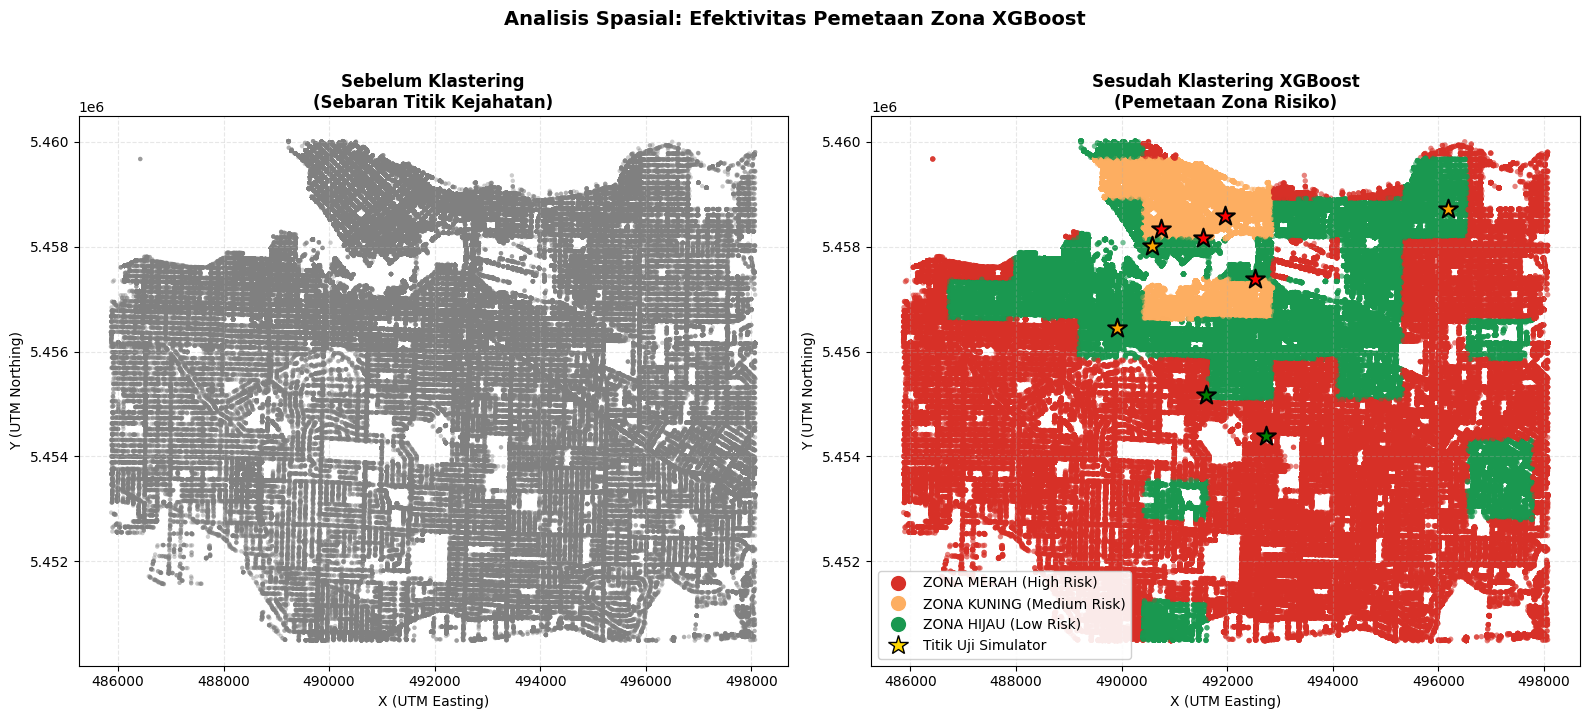

In [69]:
# Visualisasi Analisis Spasial (Sebelum & Sesudah Klastering)

# 1. Filter outlier koordinat
x_q01, x_q99 = df_clean['X'].quantile([0.01, 0.99])
y_q01, y_q99 = df_clean['Y'].quantile([0.01, 0.99])

df_plot = df_clean[
    (df_clean['X'] >= x_q01) & (df_clean['X'] <= x_q99) &
    (df_clean['Y'] >= y_q01) & (df_clean['Y'] <= y_q99)
].copy()

outlier_count = len(df_clean) - len(df_plot)
print(f' Data diplot: {len(df_plot):,} dari {len(df_clean):,} ({outlier_count} outlier dibuang)')

# 2. Definisi Warna Kustom untuk Konsistensi Visual (HIGH=Red, LOW=Green)
# Kita mapping warna: [0:Red, 1:Green, 2:Orange]
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#d73027', '#1a9850', '#fdae61']) # Merah, Hijau, Kuning

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel Kiri: Sebelum Klastering (Raw Data)
axes[0].scatter(df_plot['X'], df_plot['Y'],
                color='gray', alpha=0.4, s=10, edgecolor='none')
axes[0].set_title('Sebelum Klastering\n(Sebaran Titik Kejahatan)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X (UTM Easting)'); axes[0].set_ylabel('Y (UTM Northing)')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel Kanan: Sesudah Klastering (Zona Risiko)
# Gunakan custom_cmap agar HIGH=Merah, LOW=Hijau selalu konsisten
sc = axes[1].scatter(df_plot['X'], df_plot['Y'],
                     c=df_plot['zone_label'], cmap=custom_cmap,
                     alpha=0.6, s=15, edgecolor='none')

# Tambahkan Titik Uji Simulator
for idx in test_indices:
    row = df_clean.iloc[idx]
    # Cek apakah titik uji masuk area plot (bukan outlier)
    if not (x_q01 <= row['X'] <= x_q99 and y_q01 <= row['Y'] <= y_q99):
        continue

    result = predict_zone_xgboost(row['X'], row['Y'], row['HOUR'])
    # Warna bintang sesuai hasil prediksi simulator
    mc_color = 'red' if result['risk_score']==3 else 'orange' if result['risk_score']==2 else 'green'
    axes[1].scatter(row['X'], row['Y'], c=mc_color, s=200, edgecolor='black',
                    marker='*', zorder=5, linewidth=1.5)

axes[1].set_title('Sesudah Klastering XGBoost\n(Pemetaan Zona Risiko)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X (UTM Easting)'); axes[1].set_ylabel('Y (UTM Northing)')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Legenda yang konsisten dengan warna peta
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', markersize=12, label='ZONA MERAH (High Risk)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#fdae61', markersize=12, label='ZONA KUNING (Medium Risk)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1a9850', markersize=12, label='ZONA HIJAU (Low Risk)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=15, markeredgecolor='black', label='Titik Uji Simulator')
]
axes[1].legend(handles=legend_elements, loc='best', fontsize=10, framealpha=0.9)

plt.suptitle('Analisis Spasial: Efektivitas Pemetaan Zona XGBoost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/09_peta_zoning_kriminalitas.png', dpi=300, bbox_inches='tight')
plt.show()

## Hasil dan Pembahasan

In [71]:
# Hasil dan Pembahasan
print('='*75)
print(' HASIL DAN PEMBABAHASAN')
print('Kasus: Simulasi Pemetaan Zona Kriminalitas Vancouver')
print('Algoritma: XGBoost Classifier (Pure Implementation)')
print('='*75)

# 1. ANALISIS SPASIAL & DISTRIBUSI ZONA
print(f'\n  ANALISIS SPASIAL:')
print(f'   • Total data valid    : {len(df_clean):,} baris')
print(f'   • Zona optimal (K)    : {OPTIMAL_K} (Elbow Method, threshold {THRESHOLD_PCT}%)')
print(f'   • Fitur spasial       : Koordinat UTM (X, Y) + Grid Density')

print(f'\n    Distribusi Kejadian per Zona:')
# Loop dinamis berdasarkan urutan densitas (zona terpadat = paling rawan)
for z, risk in risk_mapping.items():
    c = (df_clean['pseudo_zone'] == z).sum()
    pct = c / len(df_clean) * 100
    # Fix: Use nested ternary for marker assignment
    marker = '🔴' if 'MERAH' in risk else ('🟡' if 'KUNING' in risk else '🟢')
    print(f'     {marker} {z: <6} → {risk: <22}: {c: >7,} ({pct: >5.1f}%)')

# 2. PERFORMA MODEL XGBOOST
print(f'\n PERFORMA MODEL XGBOOST:')
print(f'   • Akurasi Training    : {xgb_model.score(X_train, y_train)*100: >6.2f}%')
print(f'   • Akurasi Testing     : {acc*100: >6.2f}%')
print(f'   • CV 5-fold Mean      : {cv_scores.mean()*100: >6.2f}% \u00b1 {cv_scores.std()*100: >5.2f}%')

# Feature Importance Summary
print(f'\n    Top 3 Fitur Paling Berpengaruh:')
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
for i, (feat, imp) in enumerate(importances.head(3).items(), 1):
    feat_name = feat.replace('_scaled','').replace('_BIN','').replace('_SIN','').replace('_COS','').upper()
    print(f'     {i}. {feat_name: <15}: {imp*100: >5.1f}%')

# 3. VALIDASI KUALITAS ZONA (Silhouette & Jaccard)
print(f'\n VALIDASI KUALITAS ZONA:')

# Silhouette Score Interpretation
if sil_score > 0.5:
    sil_status, sil_icon = 'STRUKTUR ZONA JELAS', '✅'
elif sil_score > 0.25:
    sil_status, sil_icon = 'STRUKTUR ZONA CUKUP', '⚠️'
else:
    sil_status, sil_icon = 'STRUKTUR ZONA SAMAR', '❌'
print(f'   {sil_icon} Silhouette Score : {sil_score:.4f} \u2192 {sil_status}')

# Jaccard Index Interpretation
if jaccard > 0.8:
    jac_status, jac_icon = 'SANGAT STABIL', '🛡️'
elif jaccard > 0.6:
    jac_status, jac_icon = 'CUKUP STABIL', '⚠️'
else:
    jac_status, jac_icon = 'RENTAN PERUBAHAN', '❌'
print(f'   {jac_icon} Jaccard Index    : {jaccard:.4f} \u2192 {jac_status}')

print(f'    Konsistensi Prediksi : {consistency*100: >6.2f}%')

# 4. KESIMPULAN & REKOMENDASI STRATEGIS
print(f'\n\u02da KESIMPULAN SIMULASI:')
print(f'    Model XGBoost berhasil memetakan {OPTIMAL_K} zona risiko secara otomatis')
print(f'    Rekomendasi patroli disesuaikan dengan densitas historis & pola temporal')
print(f'    Stabilitas zona teruji terhadap gangguan koordinat (noise \u00b15%)')

print(f'\n REKOMENDASI OPERASIONAL:')
# Dynamic recommendations based on zone distribution
high_risk_pct = (df_clean['pseudo_zone'] == list(risk_mapping.keys())[0]).sum() / len(df_clean) * 100

if high_risk_pct > 40:
    print(f'    Zona MERAH dominan ({high_risk_pct:.1f}%): Prioritaskan patroli intensif 24/7')
elif high_risk_pct > 25:
    print(f'    Zona MERAH signifikan ({high_risk_pct:.1f}%): Fokuskan patroli pada jam puncak')
else:
    print(f'    Distribusi zona seimbang: Patroli reguler dengan monitoring berkala')

print(f'    Simulator siap deploy untuk input koordinat real-time')
print(f'    Model dapat di-retrain berkala dengan data terbaru')

# 5. ARTEFAK & REPRODUKTIBILITAS
print(f'\n ARTEFAK MODEL (Reproduktibilitas):')
print(f'    Lokasi penyimpanan : `{save_dir}/`')
print(f'    File tersimpan:')
for f in sorted(os.listdir(save_dir)):
    size_kb = os.path.getsize(os.path.join(save_dir, f)) / 1024
    print(f'      • {f: <25} ({size_kb: >7.1f} KB)')

print(f'\n Untuk reload model di sesi lain:')
print(f'   ```python')
print(f'   import joblib')
print(f'   model = joblib.load("{save_dir}/xgb_model.pkl")')
print(f'   scaler = joblib.load("{save_dir}/scaler_xy.pkl")')
print(f'   ```')

 HASIL DAN PEMBABAHASAN
Kasus: Simulasi Pemetaan Zona Kriminalitas Vancouver
Algoritma: XGBoost Classifier (Pure Implementation)

  ANALISIS SPASIAL:
   • Total data valid    : 476,290 baris
   • Zona optimal (K)    : 3 (Elbow Method, threshold 10%)
   • Fitur spasial       : Koordinat UTM (X, Y) + Grid Density

    Distribusi Kejadian per Zona:
     🔴 Z3     → MERAH (Sangat Rawan)  : 153,214 ( 32.2%)
     🟡 Z2     → KUNING (Rawan)        : 163,884 ( 34.4%)
     🟢 Z1     → HIJAU (Aman)          : 159,192 ( 33.4%)

 PERFORMA MODEL XGBOOST:
   • Akurasi Training    :  99.73%
   • Akurasi Testing     :  99.62%
   • CV 5-fold Mean      :  99.63% ±  0.03%

    Top 3 Fitur Paling Berpengaruh:
     1. Y              :  55.3%
     2. X              :  43.1%
     3. HOUR           :   0.6%

 VALIDASI KUALITAS ZONA:
   ❌ Silhouette Score : 0.1166 → STRUKTUR ZONA SAMAR
   🛡️ Jaccard Index    : 0.8677 → SANGAT STABIL
    Konsistensi Prediksi :  92.80%

˚ KESIMPULAN SIMULASI:
    Model XGBoost berh